# Three networks, three kinds of sensor

Each network has microwave links, point gauges and a weather radar over the same city:

| network | links | point gauges | radar |
|---|---|---|---|
| Gothenburg, OpenMRG (Jun-Aug 2015) | 728 sublinks, 10 s | 30 Netatmo PWS, 10 municipal, 1 SMHI | SMHI C-band, 5 min |
| Emilia-Romagna, OpenRainER (2021-22) | 151 links x 2, 1 min | 319 ARPAE gauges, 15 min | ARPAE, 15-min totals |
| New York City, OpenMesh (2023-24) | 103 sublinks, 1 min | 37 WU PWS, 4 ASOS | MRMS, hourly |

`core.opensense.networks` gives all three the same interface: `links()`, `points()` and
`radar_hourly()` on a regular lat/lon grid. This notebook maps one storm per network from each
sensor, with the same interpolation for links and gauges, and compares them.

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import pandas as pd

from core.opensense.networks import NETWORKS
from multisensor_maps import plots

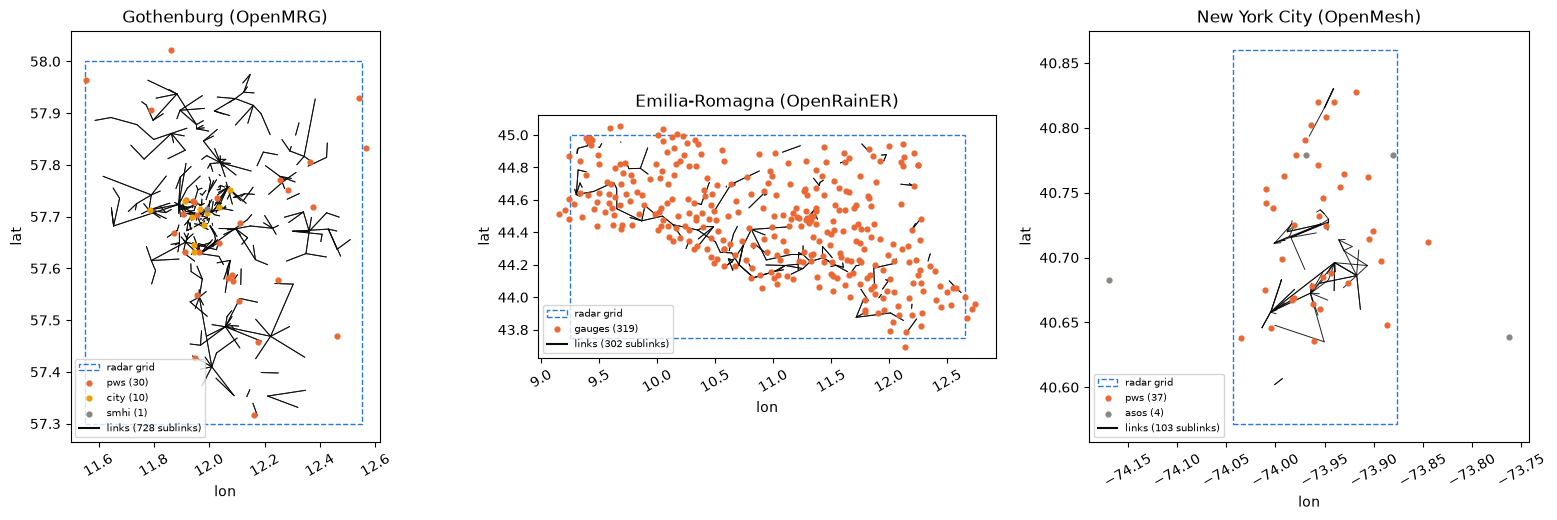

In [2]:
EVENTS = {"openmrg": ("2015-08-25 02:00", "2015-08-25 23:00"),
          "openrainer": ("2021-09-26 06:00", "2021-09-26 19:00"),
          "openmesh": ("2024-01-09 16:00", "2024-01-10 11:00")}
pts = {k: NETWORKS[k].points(*EVENTS[k]) for k in NETWORKS}
plots.networks_figure(pts);

## One storm per network

`run_event` loads the links that pass quality control and turns each into hourly rain five
ways - four power-law methods (`core.cml`) and the RNN trained in `projects/retrieval/rnn_three_networks` (these
storms are test storms for it) - then maps every retrieval three ways (`idw` from link midpoints,
`line` from points along each path, `gmz`), maps each gauge set with the same IDW, and scores
everything against everything.

In [3]:
from core.cml.rnn import HourlyRNN
from multisensor_maps.event import run_event
from multisensor_maps.settings import RNN_MODEL

results = {k: run_event(k, *EVENTS[k], extra={"rnn": HourlyRNN(RNN_MODEL, k).estimate}) for k in EVENTS}
for k, res in results.items():
    print(f"{k:11s} {res.links.sizes['link']:4d} links   maps: {', '.join(res.maps)}")

openmrg      353 links   maps: radar, pws, city, dynamic idw, dynamic line, dynamic gmz, constant idw, constant line, constant gmz, pycomlink idw, pycomlink line, pycomlink gmz, nearby idw, nearby line, nearby gmz, rnn idw, rnn line, rnn gmz
openrainer   128 links   maps: radar, gauges, dynamic idw, dynamic line, dynamic gmz, constant idw, constant line, constant gmz, pycomlink idw, pycomlink line, pycomlink gmz, nearby idw, nearby line, nearby gmz, rnn idw, rnn line, rnn gmz
openmesh      25 links   maps: radar, pws, dynamic idw, dynamic line, dynamic gmz, constant idw, constant line, constant gmz, pycomlink idw, pycomlink line, pycomlink gmz, nearby idw, nearby line, nearby gmz, rnn idw, rnn line, rnn gmz


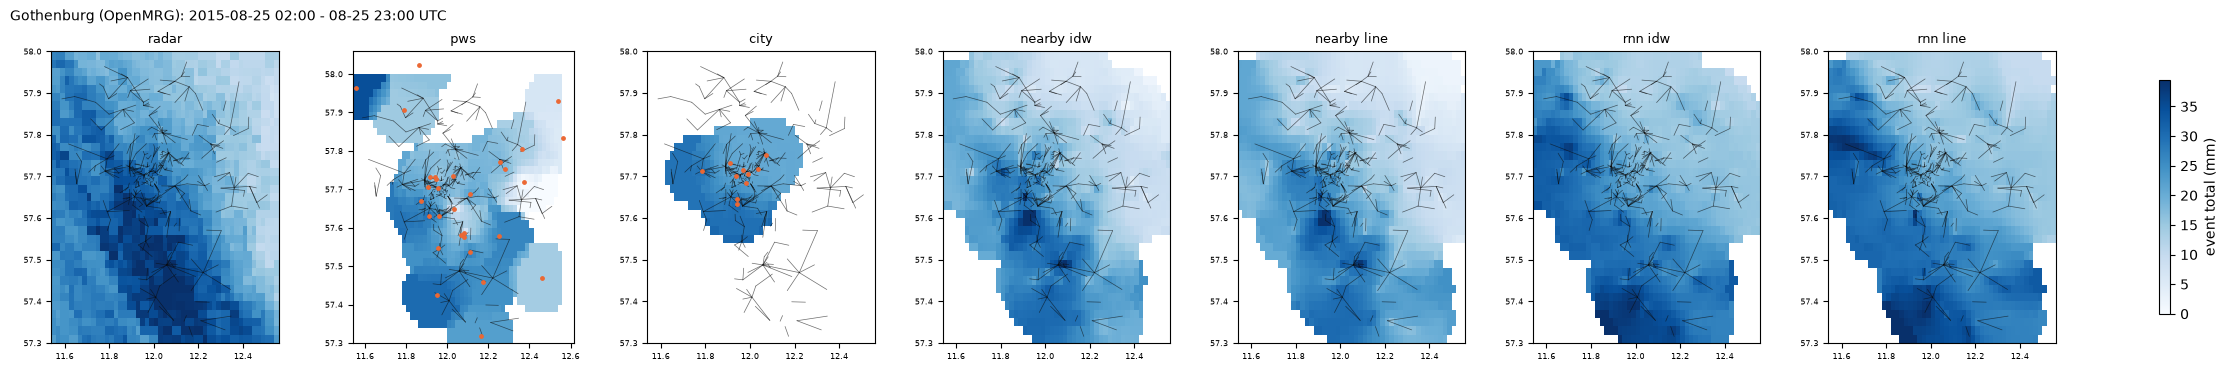

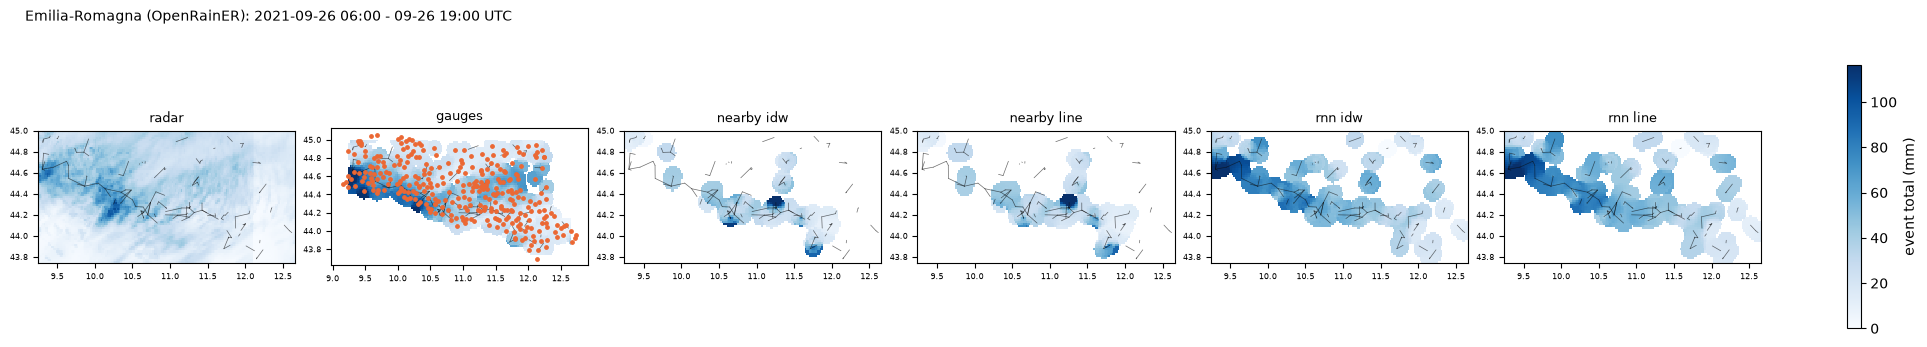

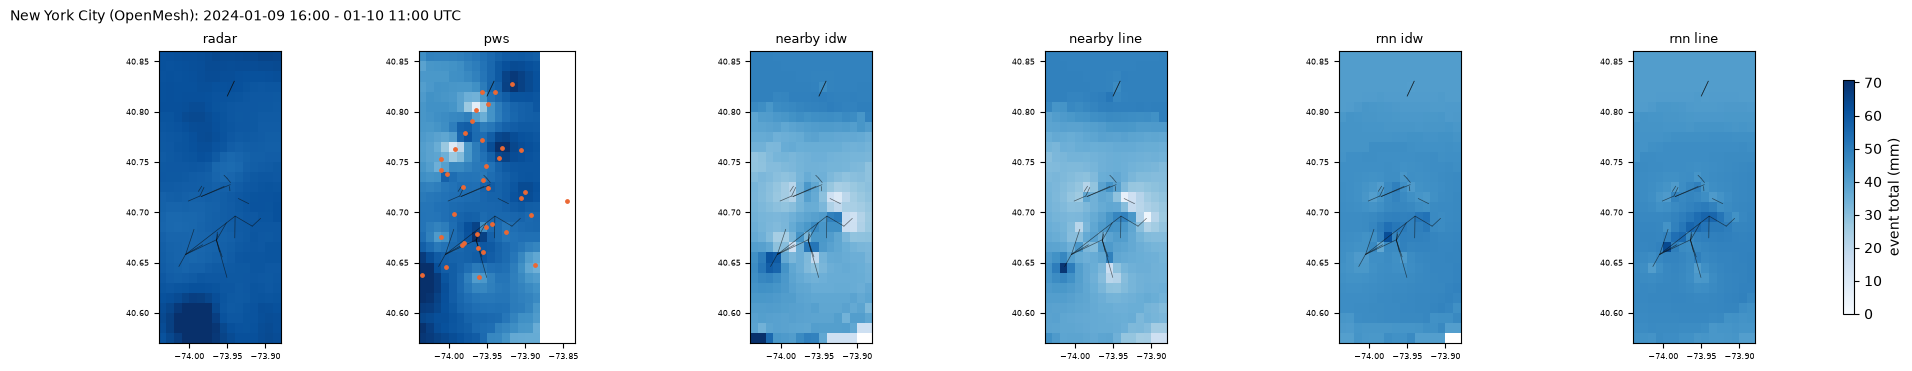

In [4]:
# radar, gauges and the idw maps of the best power law and the RNN, for readability
for res in results.values():
    keep = ["radar", *res.points, "nearby idw", "nearby line", "rnn idw", "rnn line"]
    sub = type(res)(**{**res.__dict__, "maps": {k: v for k, v in res.maps.items() if k in keep}})
    plots.event_totals_figure(sub)

## Every map against the radar, near the links

Cells within 2 km of a link, where the network actually constrains a link map.

In [5]:
table = pd.concat([r.pairwise() for r in results.values()])
(table[table.reference == "radar"].sort_values(["network", "nrmse"])
 .groupby("network").head(6)[["network", "estimate", "n", "rel_bias", "nrmse", "corr"]].round(2))

,network,estimate,n,rel_bias,nrmse,corr
0,openmesh,pws,2869,-0.06,0.32,0.95
13,openmesh,rnn idw,2869,-0.23,0.62,0.81
14,openmesh,rnn line,2869,-0.21,0.63,0.79
15,openmesh,rnn gmz,2869,-0.21,0.64,0.78
11,openmesh,nearby line,2858,-0.39,0.78,0.70
10,openmesh,nearby idw,2858,-0.38,0.78,0.70
9,openmrg,pycomlink line,17892,-0.09,0.96,0.90
8,openmrg,pycomlink idw,17892,-0.05,0.97,0.90
10,openmrg,pycomlink gmz,17892,-0.10,0.99,0.90
1,openmrg,city,5796,-0.15,1.10,0.86


## At the gauges, each left out of its own map

The fairest three-way check: at every gauge of the check set, the radar in the gauge's cell,
the link maps, and a gauge map built from all the *other* gauges.

In [6]:
pc = pd.concat([r.point_check(near_km=5) for r in results.values()])
(pc.sort_values(["network", "nrmse"]).groupby("network").head(6)
 [["network", "check", "estimate", "n", "rel_bias", "nrmse", "corr"]].round(2))

,network,check,estimate,n,rel_bias,nrmse,corr
1,openmesh,pws,radar,550,0.07,0.66,0.83
0,openmesh,pws,pws (leave-one-out),550,-0.01,0.72,0.79
14,openmesh,pws,rnn idw,550,-0.20,0.89,0.67
15,openmesh,pws,rnn line,550,-0.16,0.90,0.65
16,openmesh,pws,rnn gmz,550,-0.16,0.90,0.65
12,openmesh,pws,nearby line,548,-0.32,0.98,0.60
13,openmrg,city,nearby line,210,-0.03,0.55,0.96
2,openmrg,city,pws,210,-0.14,0.60,0.96
7,openmrg,city,constant line,210,-0.12,0.60,0.95
12,openmrg,city,nearby idw,210,0.00,0.61,0.95
